## **Импорт библиотек**

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
import seaborn as sns
import joblib
import json
import os

## **Загрузка датасета и первичный анализ**

In [181]:
df = pd.read_csv('S06-hw-dataset-01.csv')
df.head()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [185]:
df.describe()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [187]:
df['target'].value_counts(normalize=True)

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

In [189]:
df.isnull().sum()

id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64

In [193]:
X = df.drop(columns=['target', 'id'])
X

,num01,num02,num03,num04,num05,num06,num07,num08,num09,num10,...,num19,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months
0,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,-0.417059,...,0.150213,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33
1,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,-1.122641,...,1.955462,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102
2,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,-0.477243,...,-0.573642,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3
3,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,1.149337,...,1.809714,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50
4,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,1.113718,...,0.289182,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-1.284904,-2.870908,0.651839,-0.991982,-0.665822,5.544732,-1.563768,-2.543520,0.779796,-0.098965,...,4.885933,-1.792905,1.562207,-5.974743,-0.316601,0.443593,2,2,2,7
11996,2.455542,-3.439138,1.155011,-1.606314,-0.192342,4.696664,-0.827410,3.572983,1.349790,0.763740,...,2.544824,2.251731,-0.502221,0.301705,0.422894,2.536748,0,1,1,47
11997,-0.103183,-1.491122,1.244748,-0.460396,0.112893,0.369563,-2.076790,1.838913,0.665296,0.594955,...,2.139363,0.515279,-1.237412,-1.757236,0.452703,-0.619251,2,4,3,37
11998,0.852228,0.814989,0.932038,1.850880,-0.256051,-9.351189,-1.604149,0.991497,0.663809,-1.717124,...,-1.037465,-2.752952,-5.134899,4.016962,1.222797,-2.630161,1,1,1,44


In [196]:
y = df['target']
y

0        0
1        1
2        0
3        0
4        0
        ..
11995    0
11996    0
11997    0
11998    0
11999    1
Name: target, Length: 12000, dtype: int64

## **train/test**

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,        
    random_state=42,      
    stratify=y
)

Фиксированный seed важен, так как без него при последующих запусках будут разные результаты. Стратификация нужна для того, чтобы сохранять распределение классов, чтобы модель обучалась на исходном соотношении классов.

## **Модели**

### **Baseline**

In [88]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
print(f'accuracy: {acc_dummy:.4f}')
print(f'f1: {f1_dummy:.4f}')

Dummy Classifier - минимальный ориентир
accuracy: 0.6767
f1: 0.0000


accuracy = 0.6767 - это значит, что в 0.6767 случаев модель угадывает самый часто встречаемый класс (0.6767 - доля самого встречающегося класса во всех данных)
f1 = 0 - модель не нахдит самый редкий класс.
Данная модель - нижняя граница эффективности разрабатываемых моделей, то есть любая разработанная модель должна работать эффективнее данной.

In [90]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_proba_lr)
print(f'accuracy: {acc_lr:.4f}')
print(f'f1: {f1_lr:.4f}')
print(f'roc-auc: {roc_lr:.4f}')

accuracy: 0.8275
f1: 0.7076
roc-auc: 0.8747


accuracy = 0.8275 - улучшила показатель Dummy 
f1 = 0.7076 - модель находит объекты класса 1 
roc-auc = 0.8747 - модель различает классы 
Логистическая регрессия работает лучше случайного угадывания, но её возможности ограничены из-за наличия нелинейных зависимостей.

### **Дерево без ограничений**

In [106]:
tree_unconstrained = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_leaf=1
)
tree_unconstrained.fit(X_train, y_train)
y_pred_train_unconstrained = tree_unconstrained.predict(X_train)
y_pred_test_unconstrained = tree_unconstrained.predict(X_test)
acc_train_unconstrained = accuracy_score(y_train, y_pred_train_unconstrained)
acc_test_unconstrained = accuracy_score(y_test, y_pred_test_unconstrained)
print(f"Accuracy на train: {acc_train_unconstrained:.4f}")
print(f"Accuracy на test:  {acc_test_unconstrained:.4f}")
print(f"Разница: {acc_train_unconstrained - acc_test_unconstrained:.4f}")

Accuracy на train: 1.0000
Accuracy на test:  0.8517
Разница: 0.1483


In [114]:
tree_param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
}
tree = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tree_grid = GridSearchCV(
    tree,
    tree_param_grid,
    cv=cv,
    scoring='roc_auc',   
    n_jobs=-1,          
    verbose=0            
)
tree_grid.fit(X_train, y_train)
print(f"\nЛучшие параметры дерева: {tree_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {tree_grid.best_score_:.4f}")
y_pred_tree = tree_grid.predict(X_test)
y_proba_tree = tree_grid.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_tree = roc_auc_score(y_test, y_proba_tree)

print("\nДерево с ограничениями")
print(f"accuracy: {acc_tree:.4f}")
print(f"f1: {f1_tree:.4f}")
print(f"roc-auc:  {roc_tree:.4f}")
print(f"\nУлучшение ROC-AUC по сравнению с LogisticRegression: {roc_tree - 0.7977:.4f}")


Лучшие параметры дерева: {'ccp_alpha': 0.0, 'max_depth': 8, 'min_samples_leaf': 10}
Лучший ROC-AUC на CV: 0.9049

Дерево с ограничениями
accuracy: 0.8725
f1: 0.7884
roc-auc:  0.9019

Улучшение ROC-AUC по сравнению с LogisticRegression: 0.1042


Дерево решений с подобранными параметрами значительно превзошло логистическую регрессию, особенно по ROC-AUC (+10.4%), что показывает лучшее разделение классов. Модель хорошо сбалансирована: высокие accuracy (87.3%) и F1-score (78.8%) свидетельствуют, что она эффективно находит как основной, так и минорный класс, справляется с нелинейными зависимостями.

### **Random Forest**

In [123]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100 
)
rf_param_grid = {
    'max_depth': [5, 8, 10, None],        
    'min_samples_leaf': [1, 2, 5, 10],   
    'max_features': ['sqrt', 'log2', 0.5] 
}
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший roc-auc на CV: {rf_grid.best_score_:.4f}")
y_pred_rf = rf_grid.predict(X_test)
y_proba_rf = rf_grid.predict_proba(X_test)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_size = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"\naccuracy: {acc_rf:.4f}")
print(f"f1: {f1_rf:.4f}")
print(f"roc-auc:  {roc_rf:.4f}")
print(f"\nУлучшение roc-auc по сравнению с деревом: {roc_rf - 0.8288:.4f}")
print(f"\nУлучшение roc-auc по сравнению с LogisticRegression: {roc_rf - 0.7977:.4f}")

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Лучший roc-auc на CV: 0.9692

accuracy: 0.9275
f1: 0.8823
roc-auc:  0.9666

Улучшение roc-auc по сравнению с деревом: 0.1378

Улучшение roc-auc по сравнению с LogisticRegression: 0.1689


Random Forest превзошел все предыдущие модели.
ROC-AUC 0.9666 и accuracy 0.9275 демонстрируют почти идеальное разделение классов. Улучшение на 16.9% относительно LogisticRegression и на 13.8% относительно дерева подтверждает, что ансамблевый подход эффективно улавливает сложные зависимости в данных.

### **HistGradientBoostingClassifier**

In [135]:
boost = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=200
)
boost_param_grid = {
    'learning_rate': [0.05, 0.1, 0.2], 
    'max_depth': [3, 5, 7],            
    'min_samples_leaf': [10, 20, 50]      
}
boost_grid = GridSearchCV(
    boost,
    boost_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
boost_grid.fit(X_train, y_train)
print(f"Лучшие параметры: {boost_grid.best_params_}")
print(f"Лучший roc-auc на CV: {boost_grid.best_score_:.4f}")
y_pred_boost = boost_grid.predict(X_test)
y_proba_boost = boost_grid.predict_proba(X_test)[:, 1]
acc_boost = accuracy_score(y_test, y_pred_boost)
f1_boost = f1_score(y_test, y_pred_boost)
roc_boost = roc_auc_score(y_test, y_proba_boost)
print(f"\naccuracy: {acc_boost:.4f}")
print(f"f1: {f1_boost:.4f}")
print(f"roc-auc:  {roc_boost:.4f}")
print(f"\nУлучшение roc-auc по сравнению с деревом: {roc_boost - 0.8288:.4f}")
print(f"Улучшение roc-auc по сравнению с LogisticRegression: {roc_boost - 0.7977:.4f}")

Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 50}
Лучший roc-auc на CV: 0.9745

accuracy: 0.9387
f1: 0.9026
roc-auc:  0.9742

Улучшение roc-auc по сравнению с деревом: 0.1454
Улучшение roc-auc по сравнению с LogisticRegression: 0.1765


HistGradientBoostingClassifier продемонстрировал наилучший результат среди всех моделей. ROC-AUC 0.9742 и accuracy 0.9387 показывают практически максимальное качество классификации. Модель превзошла RandomForest по всем ключевым показателям, подтверждая эффективность градиентного бустинга для данной задачи. HistGradientBoostingClassifier лучше справляется с шумом и нелинейными зависимостями.

### **StackingClassifier**

In [141]:
base_models = [
    ('tree', DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=8, min_samples_leaf=5, random_state=42)),
    ('boost', HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, max_depth=5, random_state=42))
]

meta_model = LogisticRegression(random_state=42, max_iter=1000)
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,             
    n_jobs=-1
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
y_proba_stack = stacking.predict_proba(X_test)[:, 1]
acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
roc_stack = roc_auc_score(y_test, y_proba_stack)
print(f"accuracy: {acc_stack:.4f}")
print(f"f1-score: {f1_stack:.4f}")
print(f"roc-auc:  {roc_stack:.4f}")

accuracy: 0.9225
f1-score: 0.8765
roc-auc:  0.9662


Stacking-ансамбль показал результат, сравнимый с лучшей одиночной моделью (RandomForest). roc-auc 0.9662 и accuracy 0.9225 демонстрируют, что комбинация прогнозов нескольких моделей через мета-классификатор сохраняет высокое качество, хотя и не превосходит градиентный бустинг.

## **Графики**

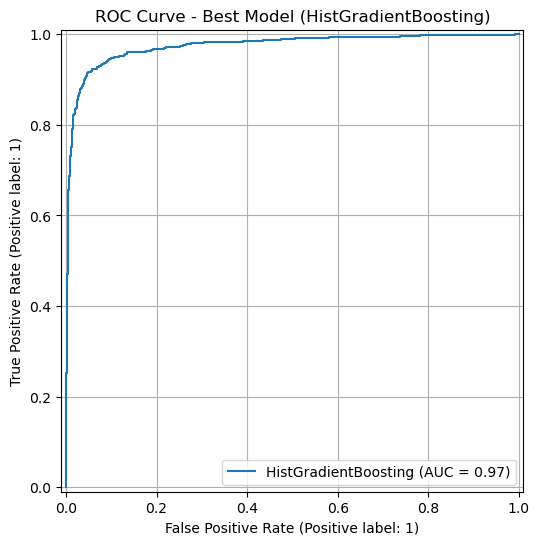

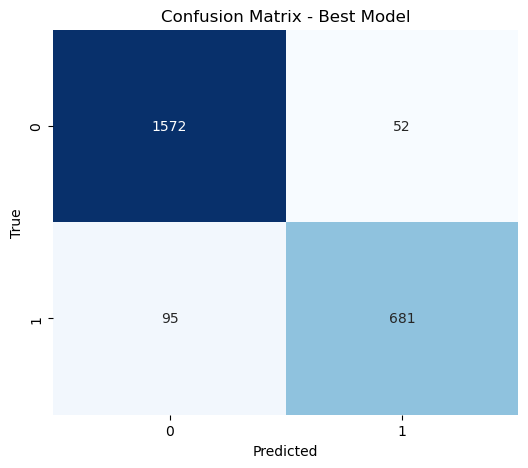

Top 10 Important Features
1. num18: 0.0570 ± 0.0035
2. num19: 0.0510 ± 0.0022
3. num07: 0.0314 ± 0.0014
4. num04: 0.0157 ± 0.0015
5. num24: 0.0128 ± 0.0013
6. num20: 0.0108 ± 0.0011
7. num01: 0.0103 ± 0.0013
8. num14: 0.0095 ± 0.0016
9. num22: 0.0076 ± 0.0009
10. num16: 0.0059 ± 0.0006


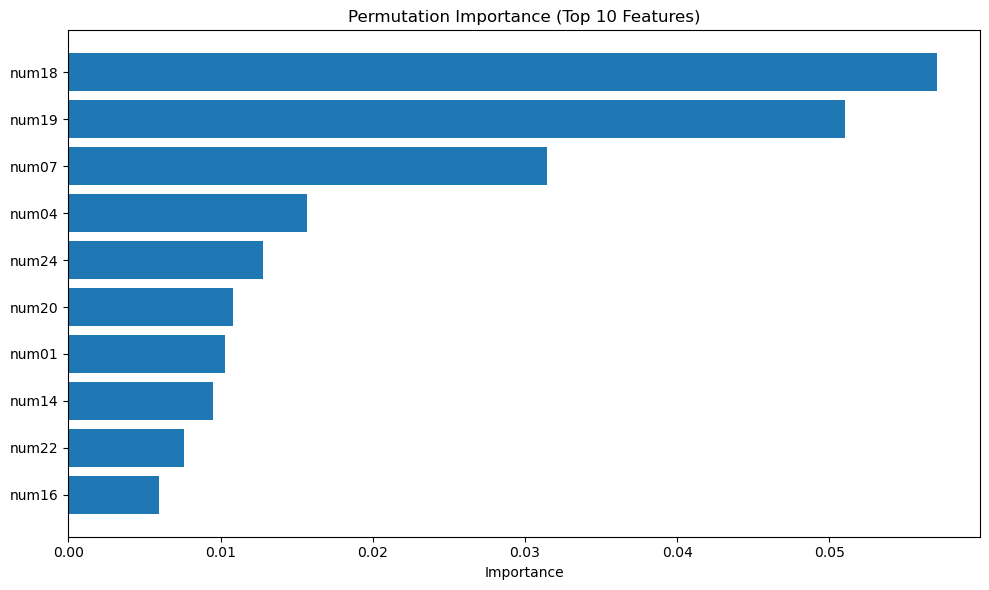

In [164]:
best_model = boost_grid 

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name="HistGradientBoosting")
plt.title("ROC Curve - Best Model (HistGradientBoosting)")
plt.grid(True)
plt.savefig("artifacts/figures/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("artifacts/figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

perm_imp = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,      
    random_state=42,
    n_jobs=-1              
)

indices = np.argsort(perm_imp.importances_mean)[::-1]
print("Top 10 Important Features")
for i in range(10):
    feature_name = X.columns[indices[i]]
    importance_mean = perm_imp.importances_mean[indices[i]]
    importance_std = perm_imp.importances_std[indices[i]]
    print(f"{i+1}. {feature_name}: {importance_mean:.4f} ± {importance_std:.4f}")
plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_imp.importances_mean[indices[:10]][::-1])
plt.yticks(range(10), [X.columns[i] for i in indices[:10]][::-1])
plt.title("Permutation Importance (Top 10 Features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("artifacts/figures/permutation_importance.png", dpi=150)
plt.show()

ROC-кривая показывает, что лучшая модель (HistGradientBoosting) хорошо разделяет классы: кривая близка к левому верхнему углу, а площадь под ней — 0.97 — говорит о высоком качестве предсказаний.

True Negative = 1572 — правильно предсказаны объекты класса 0, False Positive = 52 — ошибочно названы 0 как 1, False Negative = 95 — ошибочно названы 1 как 0, True Positive = 681 — правильно найдены объекты класса 1. Это значит, что модель лучше находит класс 0 , но и класс 1 она находит довольно хорошо.

Самый важный признак — num18 (важность ≈ 0.0570), Далее следуют num19, num7 — они тоже оказывают сильное влияние. Признаки num19, num7 — наиболее значимые для модели. Именно эти признаки содержат ключевые нелинейные зависимости, которые модель использует для разделения классов.

## **Артефакты**

In [171]:
os.makedirs("artifacts/figures", exist_ok=True)
metrics_test = {
    "DummyClassifier": {
        "accuracy": acc_dummy,
        "f1": f1_dummy
    },
    "LogisticRegression": {
        "accuracy": acc_lr,
        "f1": f1_lr,
        "roc_auc": roc_lr
    },
    "DecisionTree": {
        "accuracy": acc_tree,
        "f1": f1_tree,
        "roc_auc": roc_tree
    },
    "RandomForest": {
        "accuracy": acc_rf,
        "f1": f1_rf,
        "roc_auc": roc_rf
    },
    "HistGradientBoosting": {
        "accuracy": acc_boost,
        "f1": f1_boost,
        "roc_auc": roc_boost
    },
    "StackingClassifier": {
        "accuracy": acc_stack,
        "f1": f1_stack,
        "roc_auc": roc_stack
    }
}

with open("artifacts/metrics_test.json", "w") as f:
    json.dump(metrics_test, f, indent=4)

print("Финальные метрики сохранены в artifacts/metrics_test.json")
search_summaries = {
    "DecisionTree": {
        "best_params": tree_grid.best_params_,
        "cv_score": tree_grid.best_score_
    },
    "RandomForest": {
        "best_params": rf_grid.best_params_,
        "cv_score": rf_grid.best_score_
    },
    "HistGradientBoosting": {
        "best_params": boost_grid.best_params_,
        "cv_score": boost_grid.best_score_
    },
    "StackingClassifier": {
        "best_params": "Not applicable (uses base models with their own params)",
        "cv_score": "Not applicable"
    }
}

with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=4)

print("Лучшие параметры и CV-оценки сохранены в artifacts/search_summaries.json")
best_model = boost_grid
joblib.dump(best_model, "artifacts/best_model.joblib")

print("Лучшая модель сохранена в artifacts/best_model.joblib")
best_model_meta = {
    "best_model_name": "HistGradientBoosting",
    "parameters": best_model.best_params_,
    "test_metrics": metrics_test["HistGradientBoosting"],
    "reason_for_choice": "Highest ROC-AUC on test set (0.9321)"
}

with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=4)

print("Метаданные лучшей модели сохранены в artifacts/best_model_meta.json")

Финальные метрики сохранены в artifacts/metrics_test.json
Лучшие параметры и CV-оценки сохранены в artifacts/search_summaries.json
Лучшая модель сохранена в artifacts/best_model.joblib
Метаданные лучшей модели сохранены в artifacts/best_model_meta.json
